In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Library untuk modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

In [4]:
# Load dataset
# Pastikan path file benar sesuai struktur folder UTS
df = pd.read_csv('../dataset/agro_environmental_dataset.csv')

In [5]:
# Melihat 5 data teratas
df.head()

,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


In [6]:
# Melihat informasi dataset
print("\n--- Informasi Dataset ---")
df.info()


--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime   

In [7]:
# Cek data yang duplikat
df.duplicated().sum()

np.int64(0)

In [8]:
# Hapus data duplikat jika ada
df = df.drop_duplicates()

In [9]:
# Statistik deskriptif
print("\n--- Statistik Deskriptif ---")
display(df.describe())


--- Statistik Deskriptif ---


,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000
mean,1.319365,4.000303,17.212248,0.673847,0.610260,34.977238,16.945798,42.566326,25.003662,28.007091,699.682397,6.499156,0.206417,100.369819,50.593494,110.290247,0.613343,0.914698,0.162147
std,0.243070,4.278072,10.367455,0.986025,0.198579,11.927853,6.615230,9.681918,4.991071,5.379043,288.943448,0.892323,0.404734,39.138892,23.827609,43.769883,0.246283,0.743454,0.368586
min,0.700000,1.200000,5.000000,0.200000,0.300000,5.000000,8.000000,28.000000,10.000000,7.000000,200.000000,4.000000,0.000000,20.000000,10.000000,20.000000,0.000000,0.000000,0.000000
25%,1.300000,1.800000,8.000000,0.300000,0.400000,26.870000,12.000000,38.000000,21.600000,24.400000,450.000000,5.890000,0.000000,73.000000,33.100000,79.700000,0.457000,0.000000,0.000000
50%,1.300000,3.500000,15.000000,0.400000,0.700000,34.970000,16.000000,42.000000,25.000000,28.000000,699.000000,6.500000,0.000000,100.000000,50.100000,110.000000,0.628000,1.000000,0.000000
75%,1.500000,3.800000,20.000000,0.500000,0.700000,43.070000,22.000000,45.000000,28.400000,31.600000,949.000000,7.110000,0.000000,127.000000,66.900000,140.300000,0.784000,1.000000,0.000000
max,1.600000,18.000000,40.000000,4.000000,0.900000,70.000000,30.000000,65.000000,40.000000,49.600000,1200.000000,8.800000,1.000000,220.000000,159.000000,220.000000,1.000000,2.000000,1.000000


In [10]:
# Cek missing values
print("\nJumlah Missing Values:")
df.isnull().sum()


Jumlah Missing Values:


location_id                 0
soil_type                   0
bulk_density                0
organic_matter_pct          0
cation_exchange_capacity    0
salinity_ec                 0
buffering_capacity          0
soil_moisture_pct           0
moisture_limit_dry          0
moisture_limit_wet          0
moisture_regime             0
soil_temp_c                 0
air_temp_c                  0
thermal_regime              0
light_intensity_par         0
soil_ph                     0
ph_stress_flag              0
nitrogen_ppm                0
phosphorus_ppm              0
potassium_ppm               0
nutrient_balance            0
plant_category              0
suitability_score           0
stress_level                0
failure_flag                0
dtype: int64

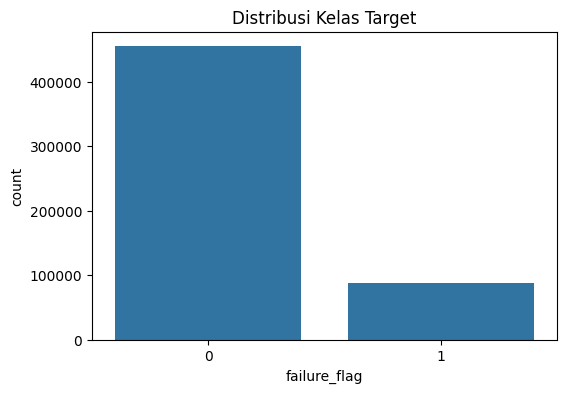

In [11]:
# Cek Imbalance kelas target
# Visualisasi distribusi kelas targe
plt.figure(figsize=(6,4))
sns.countplot(x='failure_flag', data=df)
plt.title("Distribusi Kelas Target")
plt.show()

In [12]:
# Jika ada kolom teks/kategori, kita ubah jadi angka dengan Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [13]:
# Cek apakah sekarang semuanya sudah jadi angka
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  int64  
 1   soil_type                 543210 non-null  int64  
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  int64  
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 non-null  i

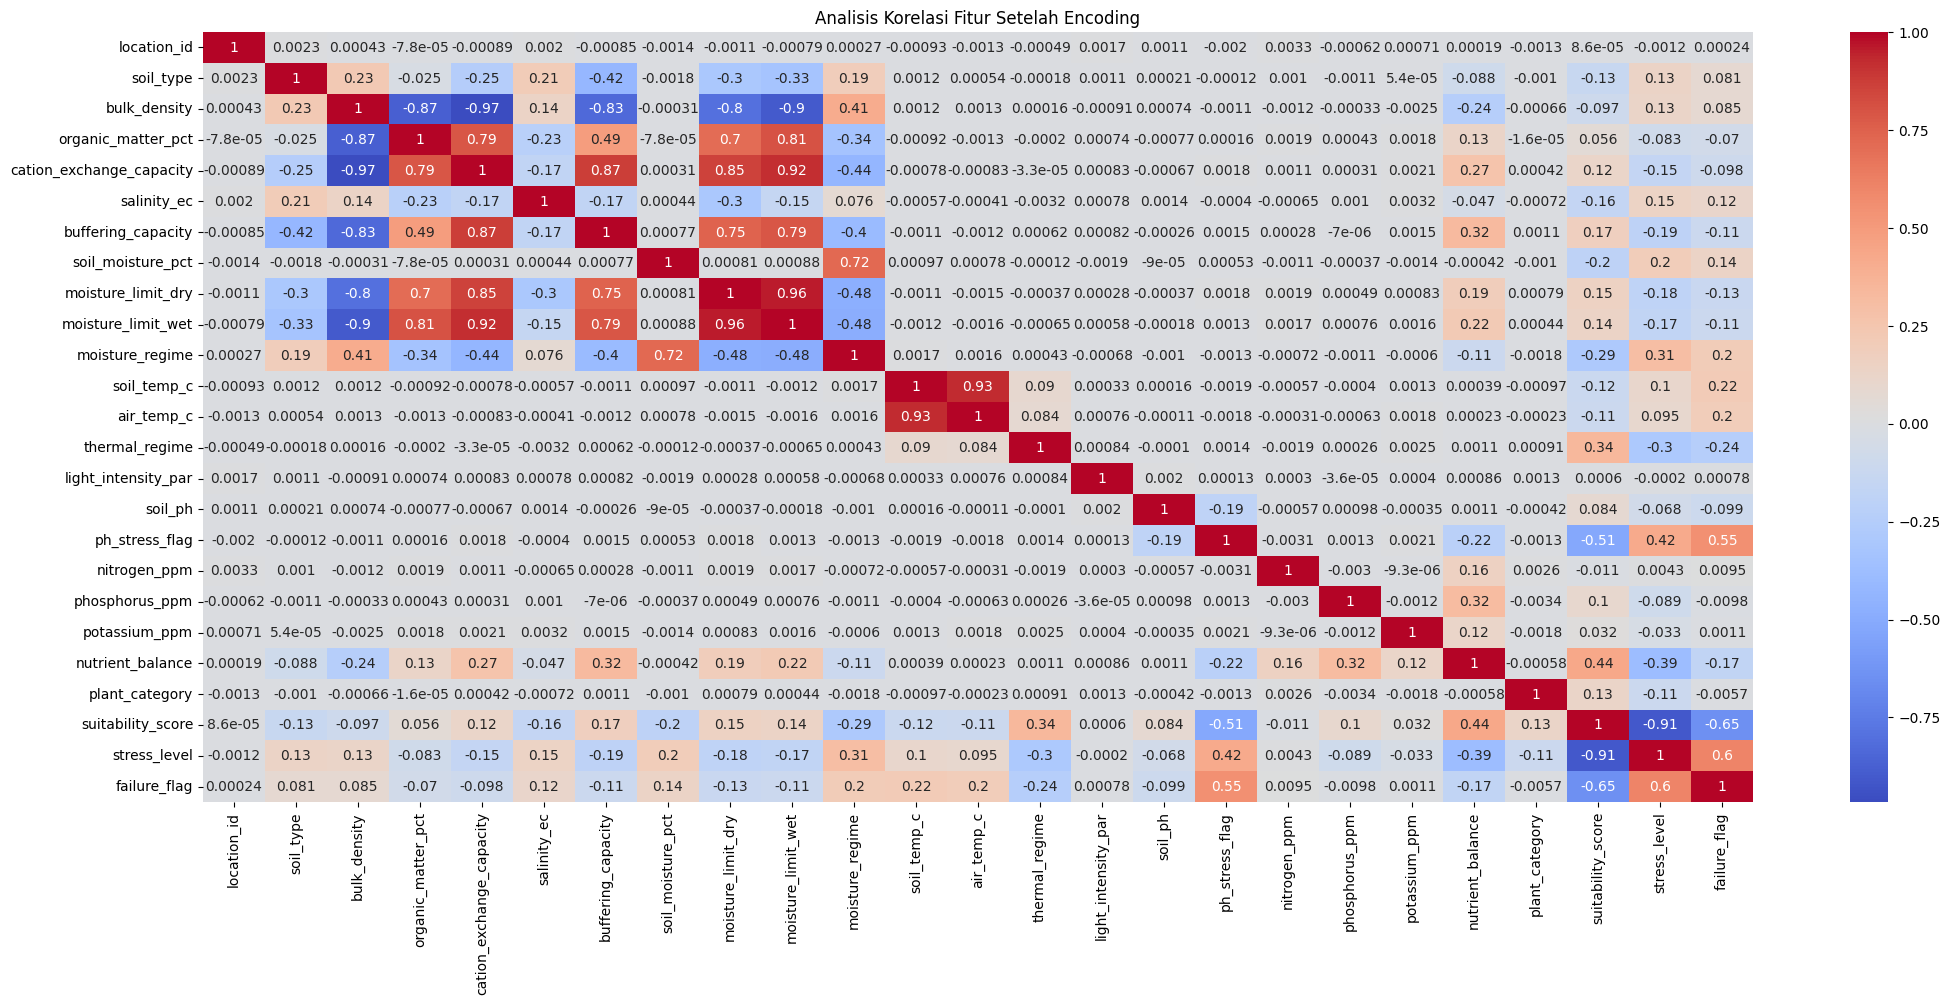

In [14]:
# Pastikan semua kolom sudah numerik
df_numeric = df.select_dtypes(include=[np.number])

# Membuat heatmap korelasi untuk melihat hubungan antar fitur
plt.figure(figsize=(25, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Analisis Korelasi Fitur Setelah Encoding")
plt.show()

In [15]:
# Hapus fitur yang korelasi 1.0 (dirinya sendiri), fitur ID, 
# dan fitur yang redundan tinggi untuk hasil model yang lebih efisien.
# HANYA gunakan fitur yang benar-benar kita kumpulkan melalui User Interface/API
features_to_use = [
    'bulk_density', 
    'organic_matter_pct', 
    'cation_exchange_capacity', 
    'salinity_ec', 
    'buffering_capacity', 
    'soil_moisture_pct', 
    'soil_temp_c', 
    # 'air_temp_c', # Sudah di drop berdasarkan EDA karena korelasi tinggi dengan soil_temp_c
    'light_intensity_par', 
    'soil_ph', 
    'moisture_regime', 
    'thermal_regime', 
    'nutrient_balance'
]

X = df[features_to_use]
y = df['failure_flag']

In [16]:
# Cek distribusi sebelum SMOTE
print("Distribusi sebelum SMOTE:\n", y.value_counts())

Distribusi sebelum SMOTE:
 failure_flag
0    455130
1     88080
Name: count, dtype: int64


In [17]:
# Split awal sebelum SMOTE agar data test tetap original
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah Data Training: {X_train_raw.shape[0]}")
print(f"Jumlah Data Testing: {X_test_raw.shape[0]}")

Jumlah Data Training: 434568
Jumlah Data Testing: 108642


In [18]:
from imblearn.over_sampling import SMOTE

# Menerapkan SMOTE hanya pada data training
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_raw, y_train)

print("Distribusi kelas setelah SMOTE:")
print(y_train_resampled.value_counts())

Distribusi kelas setelah SMOTE:
failure_flag
0    364104
1    364104
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Jumlah data training setelah SMOTE: {len(X_train_resampled)}")

Jumlah data training setelah SMOTE: 728208


In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning untuk Random Forest
# Kita perluas param_grid namun tetap efisien
param_grid = {
    'n_estimators': [100, 200],  # Menambah jumlah pohon untuk menangkap pola dari 500rb+ data
    'max_depth': [15, 25],        # Kedalaman yang lebih tinggi cocok untuk data besar
    'min_samples_split': [10],    # Nilai sedikit lebih tinggi untuk mencegah overfitting pada data masif
    'max_features': ['sqrt']      # Mengurangi beban memori
}

# Gunakan n_jobs=-1 untuk memakai semua core CPU laptopmu
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, 
    param_grid, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2 # Verbose 2 akan memunculkan progres tiap iterasi agar kamu tahu prosesnya jalan
)

print("Memulai Hyperparameter Tuning pada seluruh dataset...")
grid_search.fit(X_train_scaled, y_train_resampled) # Pastikan variabel X_train_scaled adalah hasil scaling full data

best_rf = grid_search.best_estimator_
print(f"Parameter terbaik: {grid_search.best_params_}")

Memulai Hyperparameter Tuning pada seluruh dataset...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Parameter terbaik: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# Ensemble Learning (Voting Classifier)
print("Melatih Gradient Boosting dan Ensemble (Voting)...")
gb = GradientBoostingClassifier(
    random_state=42, 
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5 # Tidak terlalu dalam agar komputasi tidak stuck
)

# Gabungkan dengan Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[('rf', best_rf), ('gb', gb)],
    voting='soft' # Mempertimbangkan nilai probabilitas (kepercayaan model)
)

ensemble_model.fit(X_train_scaled, y_train_resampled)
print(" Pelatihan Ensemble Model pada seluruh data selesai!")

Melatih Gradient Boosting dan Ensemble (Voting)...


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Prediksi pada data Test dan Train (untuk cek overfitting)
y_pred_test = ensemble_model.predict(X_test_scaled)
y_pred_train = ensemble_model.predict(X_train_scaled)

In [ ]:
# Metrik Evaluasi
print("--- Laporan Klasifikasi (Data Testing) ---")
print(classification_report(y_test, y_pred_test))

acc_test = accuracy_score(y_test, y_pred_test) * 100
acc_train = accuracy_score(y_train_resampled, y_pred_train) * 100

print(f"Accuracy Data Training: {acc_train:.2f}%")
print(f"Accuracy Data Testing: {acc_test:.2f}%")

--- Laporan Klasifikasi (Data Testing) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91026
           1       1.00      1.00      1.00     17616

    accuracy                           1.00    108642
   macro avg       1.00      1.00      1.00    108642
weighted avg       1.00      1.00      1.00    108642

Accuracy Data Training: 99.98%
Accuracy Data Testing: 99.99%


In [ ]:
# Hitung Akurasi
acc_test = accuracy_score(y_test, y_pred_test) * 100
print(f"Akurasi Model pada Data Testing: {acc_test:.2f}%")

--- Laporan Klasifikasi (Data Testing) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91026
           1       1.00      1.00      1.00     17616

    accuracy                           1.00    108642
   macro avg       1.00      1.00      1.00    108642
weighted avg       1.00      1.00      1.00    108642

Accuracy Data Training: 99.98%
Accuracy Data Testing: 99.99%


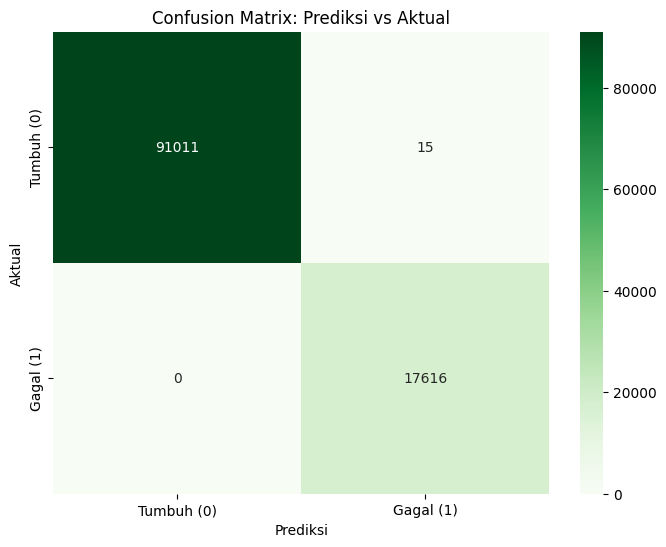

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Tumbuh (0)', 'Gagal (1)'], 
            yticklabels=['Tumbuh (0)', 'Gagal (1)'])
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

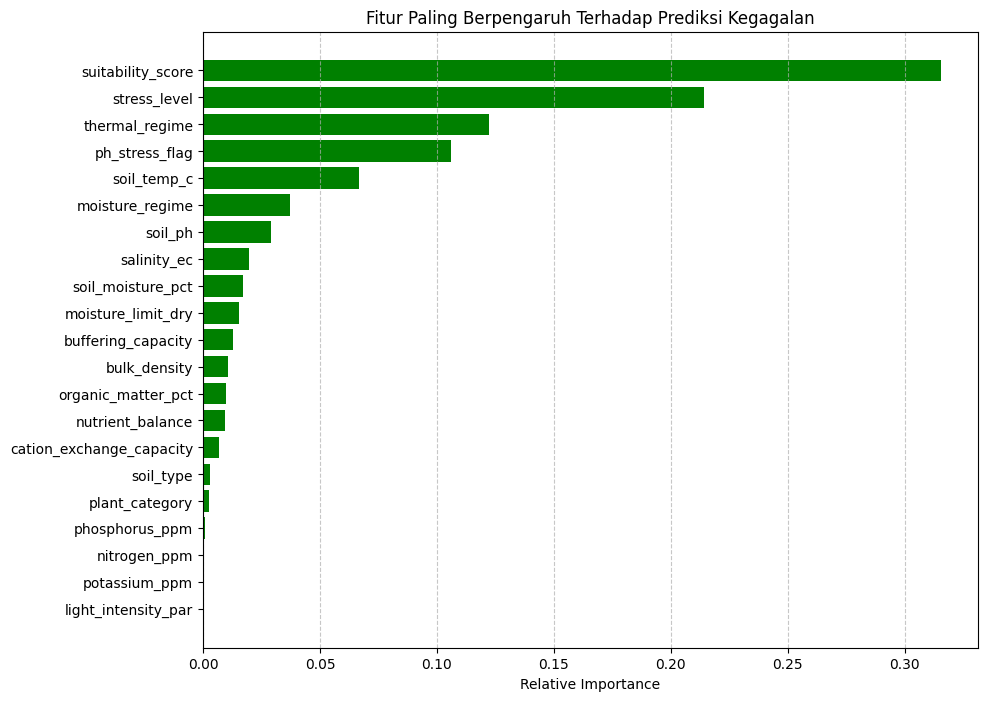

In [ ]:
# Fitur Paling Berpengaruh (Feature Importance)
# Mengambil data dari Random Forest di dalam ensemble
importances = ensemble_model.named_estimators_['rf'].feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Fitur Paling Berpengaruh Terhadap Prediksi Kegagalan')
plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [21]:
# PENYIMPANAN ASSET (WAJIB) SIMPAN MODEL & ASSET (Crucial untuk FastAPI)
# Pastikan folder '../model/' sudah ada di direktori proyekmu
joblib.dump(ensemble_model, '../model/model_final.pkl')
joblib.dump(scaler, '../model/scaler.pkl')
joblib.dump(X.columns.tolist(), '../model/feature_names.pkl')

print("Model, Scaler, dan Feature Names berhasil disimpan!")

NameError: name 'ensemble_model' is not defined